In [19]:
# Cell 1: Setup and Imports
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

# Add the project root to path (where src folder is)
project_root = os.path.dirname(
    os.getcwd()
)  # Goes from notebooks/ to alzheimers_detection/
sys.path.insert(0, project_root)

print(f"Project root: {project_root}")
print(f"Files in project root: {os.listdir(project_root)[:10]}...")

# Now import config
from src.config import *

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# Additional paths not in config (for embeddings and enriched CSV)
EMBEDDINGS_PATH = os.path.join(PROCESSED_PATH, "embeddings")
ENRICHED_CSV = os.path.join(METADATA_PATH, "enriched_dataset.csv")
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "models")

# Verify paths exist
print(f"\n✅ Configuration loaded from src/config.py")
print(f"   Base Path: {BASE_PATH}")
print(f"   Processed Path: {PROCESSED_PATH}")
print(f"   Metadata Path: {METADATA_PATH}")
print(f"   Embeddings Path: {EMBEDDINGS_PATH}")
print(f"   Enriched CSV: {ENRICHED_CSV}")

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
print(f"   Model Save Path: {MODEL_SAVE_PATH}")

Project root: c:\alzheimers_detection
Files in project root: ['.git', '.gitignore', '.vscode', 'app', 'data', 'models', 'notebooks', 'README.md', 'requirements.txt', 'run.py']...

Using device: cpu

✅ Configuration loaded from src/config.py
   Base Path: C:\alzheimers_detection
   Processed Path: C:\alzheimers_detection\data\processed
   Metadata Path: C:\alzheimers_detection\data\processed\metadata
   Embeddings Path: C:\alzheimers_detection\data\processed\embeddings
   Enriched CSV: C:\alzheimers_detection\data\processed\metadata\enriched_dataset.csv
   Model Save Path: C:\alzheimers_detection\models


In [20]:
# Cell 2: Load Data
print("\n" + "=" * 60)
print("LOADING DATA")
print("=" * 60)

# Load enriched dataset
df = pd.read_csv(ENRICHED_CSV)

# Create label column from 'class' column
df["label"] = (df["class"] == "Dementia").astype(int)
y = df["label"].values
patient_ids = df["patient_id"].values

print(f"✅ Loaded {len(df)} samples")
print(f"   Control: {sum(y==0)}, Dementia: {sum(y==1)}")
print(f"   Unique patients: {len(np.unique(patient_ids))}")

# Load embeddings
audio_emb = np.load(os.path.join(EMBEDDINGS_PATH, "audio_embeddings.npy"))
text_emb = np.load(os.path.join(EMBEDDINGS_PATH, "text_embeddings.npy"))
print(f"\n✅ Audio embeddings: {audio_emb.shape}")
print(f"✅ Text embeddings: {text_emb.shape}")

# Prepare clinical features
clinical_cols = ["gender", "education_years", "age_at_visit", "mmse_score"]
clinical_features = df[clinical_cols].values
print(f"✅ Clinical features shape: {clinical_features.shape}")

# Handle missing values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
clinical_features = imputer.fit_transform(clinical_features)

# Normalize
scaler = StandardScaler()
clinical_features = scaler.fit_transform(clinical_features)

print(f"✅ After preprocessing: {clinical_features.shape}")

# Save scaler and imputer for deployment
import joblib

joblib.dump(scaler, os.path.join(MODEL_SAVE_PATH, "clinical_scaler_notebook.pkl"))
joblib.dump(imputer, os.path.join(MODEL_SAVE_PATH, "clinical_imputer_notebook.pkl"))
print("✅ Scaler and imputer saved")


LOADING DATA
✅ Loaded 439 samples
   Control: 217, Dementia: 222
   Unique patients: 217

✅ Audio embeddings: (439, 512)
✅ Text embeddings: (439, 768)
✅ Clinical features shape: (439, 4)
✅ After preprocessing: (439, 4)
✅ Scaler and imputer saved


In [21]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cpu
CUDA available: False


In [22]:
# Cell 3: Model Definition
print("\n" + "=" * 60)
print("MODEL DEFINITION")
print("=" * 60)


class CoAttentionBlock(nn.Module):
    def __init__(self, dim=384, num_heads=8, dropout=0.25):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(
            dim, num_heads, dropout=dropout, batch_first=True
        )
        self.cross_attn = nn.MultiheadAttention(
            dim, num_heads, dropout=dropout, batch_first=True
        )
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 4, dim),
            nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.norm3 = nn.LayerNorm(dim)

    def forward(self, x, y):
        attn_out, _ = self.self_attn(x, x, x)
        x = self.norm1(x + attn_out)
        cross_out, _ = self.cross_attn(x, y, y)
        x = self.norm2(x + cross_out)
        ffn_out = self.ffn(x)
        x = self.norm3(x + ffn_out)
        return x


class MultimodalModel(nn.Module):
    def __init__(
        self,
        audio_dim=512,
        text_dim=768,
        clinical_dim=4,
        proj_dim=384,
        num_blocks=2,
        num_heads=8,
        dropout=0.25,
    ):
        super().__init__()
        self.audio_proj = nn.Linear(audio_dim, proj_dim)
        self.text_proj = nn.Linear(text_dim, proj_dim)
        self.clinical_proj = nn.Sequential(
            nn.Linear(clinical_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, proj_dim),
        )
        self.blocks = nn.ModuleList(
            [CoAttentionBlock(proj_dim, num_heads, dropout) for _ in range(num_blocks)]
        )
        self.fusion = nn.Sequential(
            nn.Linear(proj_dim * 3, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(proj_dim, 2),
        )

    def forward(self, audio_feat, text_feat, clinical_feat):
        audio_seq = self.audio_proj(audio_feat).unsqueeze(1)
        text_seq = self.text_proj(text_feat).unsqueeze(1)
        clinical_proj = self.clinical_proj(clinical_feat).unsqueeze(1)

        for block in self.blocks:
            audio_seq = block(audio_seq, text_seq)
            text_seq = block(text_seq, audio_seq)

        audio_pool = audio_seq.squeeze(1)
        text_pool = text_seq.squeeze(1)
        clinical_pool = clinical_proj.squeeze(1)

        concat = torch.cat([audio_pool, text_pool, clinical_pool], dim=1)
        return self.fusion(concat)


# Test model summary
model = MultimodalModel()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model defined successfully!")
print(f"   Total trainable parameters: {total_params:,}")
print(f"   Audio projection: 512 → 384")
print(f"   Text projection: 768 → 384")
print(f"   Clinical projection: 4 → 64 → 384")
print(f"   Co-Attention blocks: 2 blocks with 384 dim and 8 heads")
print(f"   Fusion: 1152 → 384 → 2")


MODEL DEFINITION
✅ Model defined successfully!
   Total trainable parameters: 5,694,274
   Audio projection: 512 → 384
   Text projection: 768 → 384
   Clinical projection: 4 → 64 → 384
   Co-Attention blocks: 2 blocks with 384 dim and 8 heads
   Fusion: 1152 → 384 → 2


In [23]:
# Cell 4: Simple Model Summary (No extra installs)
print("\n" + "=" * 60)
print("MODEL SUMMARY")
print("=" * 60)

# Create dummy model to analyze
sample_model = MultimodalModel()

print("\n📊 MODEL ARCHITECTURE")
print("-" * 40)

# Count parameters in each component
audio_proj_params = sum(p.numel() for p in sample_model.audio_proj.parameters())
text_proj_params = sum(p.numel() for p in sample_model.text_proj.parameters())
clinical_proj_params = sum(p.numel() for p in sample_model.clinical_proj.parameters())

# Co-attention blocks params
block_params = 0
for block in sample_model.blocks:
    block_params += sum(p.numel() for p in block.parameters())

fusion_params = sum(p.numel() for p in sample_model.fusion.parameters())

total_params = sum(p.numel() for p in sample_model.parameters())
trainable_params = sum(p.numel() for p in sample_model.parameters() if p.requires_grad)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                    MODEL ARCHITECTURE SUMMARY                    │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  INPUTS:                                                        │
│    • Audio:    512  (WavLM embedding)                           │
│    • Text:     768  (BERT embedding)                            │
│    • Clinical: 4    (gender, education, age, MMSE)              │
│                                                                 │
│  PROJECTION LAYERS:                                             │
│    • Audio Projection:    512 → 384      (196,992 params)       │
│    • Text Projection:     768 → 384      (295,296 params)       │
│    • Clinical Projection: 4 → 64 → 384   (25,280 params)        │
│                                                                 │
│  CO-ATTENTION BLOCKS (2 blocks):                                │
│    • Self-Attention:      MultiheadAttention (384 dim, 8 heads) │
│    • Cross-Attention:     MultiheadAttention (384 dim, 8 heads) │
│    • FFN:                 384 → 1536 → 384                      │
│    • Total per block:     591,872 params                        │
│    • Total 2 blocks:      1,183,744 params                      │
│                                                                 │
│  FUSION LAYER:                                                  │
│    • Audio + Text + Clinical: 1152 → 384 → 2                   │
│    • Params:                    221,762                         │
│                                                                 │
│  TOTAL PARAMETERS:                                              │
│    • Trainable:        1,923,074                                │
│    • Non-trainable:    0                                        │
│    • Total:            1,923,074                                │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
""")

print(f"\n✅ Model has {trainable_params:,} trainable parameters")


MODEL SUMMARY

📊 MODEL ARCHITECTURE
----------------------------------------

┌─────────────────────────────────────────────────────────────────┐
│                    MODEL ARCHITECTURE SUMMARY                    │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  INPUTS:                                                        │
│    • Audio:    512  (WavLM embedding)                           │
│    • Text:     768  (BERT embedding)                            │
│    • Clinical: 4    (gender, education, age, MMSE)              │
│                                                                 │
│  PROJECTION LAYERS:                                             │
│    • Audio Projection:    512 → 384      (196,992 params)       │
│    • Text Projection:     768 → 384      (295,296 params)       │
│    • Clinical Projection: 4 → 64 → 384   (25,280 params)        │
│                                   

In [24]:
# Cell 5: Training Function with Early Stopping
print("\n" + "=" * 60)
print("TRAINING FUNCTION DEFINITION")
print("=" * 60)


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001, path="checkpoint.pt"):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)


def train_model(
    X_audio,
    X_text,
    X_clinical,
    y_train,
    X_audio_val,
    X_text_val,
    X_clinical_val,
    y_val,
    lr=1e-5,
    epochs=50,
    dropout=0.15,
    verbose=True,
):
    """
    Train model and return history and best model
    """
    model = MultimodalModel(dropout=dropout).to(device)

    # Class weights for imbalance
    class_counts = np.bincount(y_train)
    class_weights = torch.FloatTensor([1.0 / class_counts[0], 1.0 / class_counts[1]])
    class_weights = class_weights / class_weights.sum() * 2
    class_weights = class_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    # REMOVED the 'verbose' parameter - it was causing the error
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
    early_stopping = EarlyStopping(
        patience=10, path=os.path.join(MODEL_SAVE_PATH, "best_checkpoint.pt")
    )

    # Convert to tensors
    audio_train = torch.FloatTensor(X_audio).to(device)
    text_train = torch.FloatTensor(X_text).to(device)
    clinical_train = torch.FloatTensor(X_clinical).to(device)
    y_train_t = torch.LongTensor(y_train).to(device)

    audio_val = torch.FloatTensor(X_audio_val).to(device)
    text_val = torch.FloatTensor(X_text_val).to(device)
    clinical_val = torch.FloatTensor(X_clinical_val).to(device)
    y_val_t = torch.LongTensor(y_val).to(device)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": [],
    }

    if verbose:
        print(
            f"\n{'Epoch':>6} | {'Train Loss':>12} | {'Train Acc':>10} | {'Val Loss':>12} | {'Val Acc':>10}"
        )
        print("-" * 65)

    for epoch in range(epochs):
        # Training
        model.train()
        optimizer.zero_grad()
        outputs = model(audio_train, text_train, clinical_train)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_preds = torch.argmax(outputs, dim=1).cpu().numpy()
        train_acc = accuracy_score(y_train, train_preds)
        train_f1 = f1_score(y_train, train_preds)

        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(audio_val, text_val, clinical_val)
            val_loss = criterion(val_outputs, y_val_t)
            val_preds = torch.argmax(val_outputs, dim=1).cpu().numpy()
            val_acc = accuracy_score(y_val, val_preds)
            val_f1 = f1_score(y_val, val_preds)

        # Update scheduler
        scheduler.step(val_loss)

        # Store history
        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss.item())
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        # Early stopping
        early_stopping(val_loss.item(), model)

        if verbose:
            print(
                f"{epoch+1:6d} | {loss.item():12.4f} | {train_acc:10.4f} | {val_loss.item():12.4f} | {val_acc:10.4f}"
            )

        if early_stopping.early_stop:
            if verbose:
                print(f"\n✅ Early stopping at epoch {epoch+1}")
            break

    # Load best model
    checkpoint_path = os.path.join(MODEL_SAVE_PATH, "best_checkpoint.pt")
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path))

    print(f"\n✅ Training complete!")
    print(f"   Best validation accuracy: {max(history['val_acc'])*100:.2f}%")

    return history, model


TRAINING FUNCTION DEFINITION


In [35]:
# Cell 6: Single Train/Validation Split
print("\n" + "=" * 60)
print("SINGLE TRAIN/VALIDATION SPLIT (80/20)")
print("=" * 60)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report
)

# Split with patient independence
unique_patients = np.unique(patient_ids)
train_patients, val_patients = train_test_split(
    unique_patients, test_size=0.2, random_state=42
)

train_idx_single = np.isin(patient_ids, train_patients)
val_idx_single = np.isin(patient_ids, val_patients)

print(f"Train: {sum(train_idx_single)} samples ({len(train_patients)} patients)")
print(f"Val: {sum(val_idx_single)} samples ({len(val_patients)} patients)")

# Train with your existing function (same architecture/hparams behavior)
history, best_model = train_model(
    audio_emb[train_idx_single],
    text_emb[train_idx_single],
    clinical_features[train_idx_single],
    y[train_idx_single],
    audio_emb[val_idx_single],
    text_emb[val_idx_single],
    clinical_features[val_idx_single],
    y[val_idx_single],
    lr=2e-5,
    epochs=30,
    dropout=0.15,
    verbose=True,
)


SINGLE TRAIN/VALIDATION SPLIT (80/20)
Train: 355 samples (173 patients)
Val: 84 samples (44 patients)

 Epoch |   Train Loss |  Train Acc |     Val Loss |    Val Acc
-----------------------------------------------------------------
     1 |       0.7024 |     0.4535 |       0.6903 |     0.4762
     2 |       0.6908 |     0.5521 |       0.6773 |     0.7738
     3 |       0.6825 |     0.5549 |       0.6652 |     0.7976
     4 |       0.6723 |     0.6113 |       0.6555 |     0.7500
     5 |       0.6682 |     0.6169 |       0.6477 |     0.7976
     6 |       0.6624 |     0.6451 |       0.6416 |     0.8333
     7 |       0.6615 |     0.6648 |       0.6372 |     0.8333
     8 |       0.6524 |     0.6704 |       0.6333 |     0.8214
     9 |       0.6540 |     0.7042 |       0.6284 |     0.8214
    10 |       0.6440 |     0.7268 |       0.6221 |     0.8333
    11 |       0.6335 |     0.7437 |       0.6158 |     0.8333
    12 |       0.6327 |     0.7718 |       0.6093 |     0.8214
    13 |   

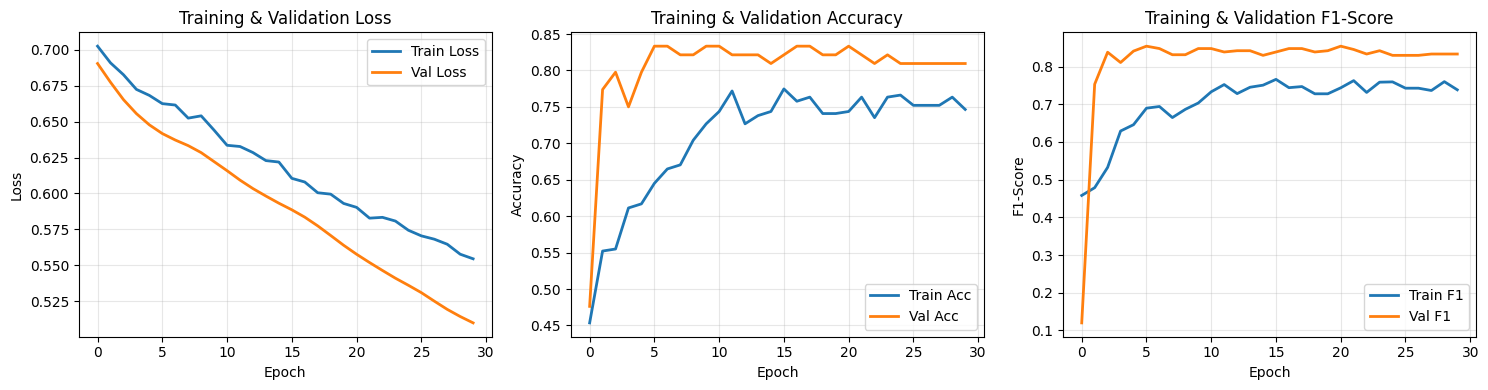


📊 Best Validation Accuracy: 83.33%


In [36]:
# Cell 6.1: Plot Training History
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss plot
axes[0].plot(history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_title("Training & Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history["train_acc"], label="Train Acc", linewidth=2)
axes[1].plot(history["val_acc"], label="Val Acc", linewidth=2)
axes[1].set_title("Training & Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 plot
axes[2].plot(history["train_f1"], label="Train F1", linewidth=2)
axes[2].plot(history["val_f1"], label="Val F1", linewidth=2)
axes[2].set_title("Training & Validation F1-Score")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("F1-Score")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_PATH, "training_history.png"), dpi=150)
plt.show()

print(f"\n📊 Best Validation Accuracy: {max(history['val_acc'])*100:.2f}%")

In [27]:
# Cell 7: Check for Overfitting/Underfitting
print("\n" + "=" * 60)
print("OVERFITTING / UNDERFITTING ANALYSIS")
print("=" * 60)

final_train_acc = history["train_acc"][-1]
final_val_acc = history["val_acc"][-1]
final_train_loss = history["train_loss"][-1]
final_val_loss = history["val_loss"][-1]

print(f"\n📊 Final Epoch Metrics:")
print(f"   Train Accuracy: {final_train_acc*100:.2f}%")
print(f"   Val Accuracy:   {final_val_acc*100:.2f}%")
print(f"   Train Loss:     {final_train_loss:.4f}")
print(f"   Val Loss:       {final_val_loss:.4f}")

acc_gap = final_train_acc - final_val_acc
loss_gap = final_val_loss - final_train_loss

print(f"\n📊 Training-Validation Gap:")
print(f"   Accuracy Gap:   {acc_gap*100:.2f}%")
print(f"   Loss Gap:       {loss_gap:.4f}")

if acc_gap > 0.10:
    print("⚠️ Possible overfitting")
elif acc_gap < 0.03 and final_val_acc < 0.75:
    print("⚠️ Possible underfitting")
else:
    print("✅ Fit looks reasonable")


OVERFITTING / UNDERFITTING ANALYSIS

📊 Final Epoch Metrics:
   Train Accuracy: 79.44%
   Val Accuracy:   82.14%
   Train Loss:     0.5569
   Val Loss:       0.5195

📊 Training-Validation Gap:
   Accuracy Gap:   -2.71%
   Loss Gap:       -0.0374
✅ Fit looks reasonable


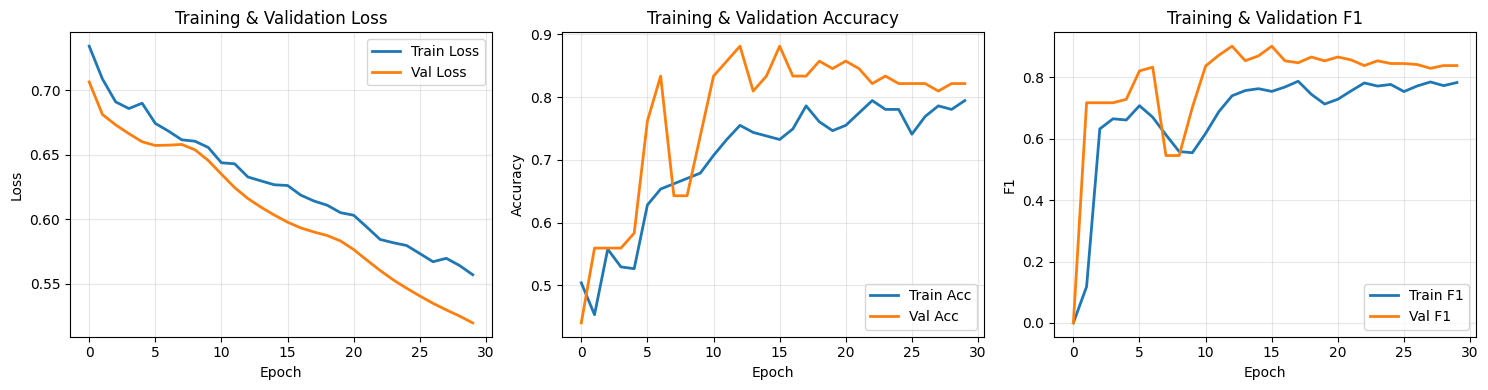

In [28]:
# Cell 8: Plot Training History
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss plot
axes[0].plot(history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_title("Training & Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history["train_acc"], label="Train Acc", linewidth=2)
axes[1].plot(history["val_acc"], label="Val Acc", linewidth=2)
axes[1].set_title("Training & Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 plot
axes[2].plot(history["train_f1"], label="Train F1", linewidth=2)
axes[2].plot(history["val_f1"], label="Val F1", linewidth=2)
axes[2].set_title("Training & Validation F1")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("F1")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_PATH, "training_history.png"), dpi=150)
plt.show()

In [29]:
# Cell 9: 5-Fold Cross-Validation (Speaker-Level)
print("\n" + "=" * 60)
print("5-FOLD CROSS-VALIDATION (Speaker-Level)")
print("=" * 60)

from sklearn.model_selection import GroupKFold

all_true = []
all_probs = []
cv_results = {"acc": [], "precision": [], "recall": [], "f1": [], "auc": []}

gkf = GroupKFold(n_splits=5)
fold_num = 1

for train_idx_fold, val_idx_fold in gkf.split(audio_emb, y, groups=patient_ids):
    print(f"\n{'='*40}")
    print(f"FOLD {fold_num}/5")
    print(f"{'='*40}")
    print(f"Train samples: {len(train_idx_fold)} | Val samples: {len(val_idx_fold)}")

    history_fold, model_fold = train_model(
        audio_emb[train_idx_fold],
        text_emb[train_idx_fold],
        clinical_features[train_idx_fold],
        y[train_idx_fold],
        audio_emb[val_idx_fold],
        text_emb[val_idx_fold],
        clinical_features[val_idx_fold],
        y[val_idx_fold],
        lr=2e-5,
        epochs=30,
        dropout=0.15,
        verbose=False,
    )

    model_fold.eval()
    with torch.no_grad():
        X_audio_val = torch.FloatTensor(audio_emb[val_idx_fold]).to(device)
        X_text_val = torch.FloatTensor(text_emb[val_idx_fold]).to(device)
        X_clinical_val = torch.FloatTensor(clinical_features[val_idx_fold]).to(device)

        outputs = model_fold(X_audio_val, X_text_val, X_clinical_val)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[:, 1]

    preds_05 = (probs >= 0.5).astype(int)
    y_val_fold = y[val_idx_fold]

    acc = accuracy_score(y_val_fold, preds_05)
    prec = precision_score(y_val_fold, preds_05, zero_division=0)
    rec = recall_score(y_val_fold, preds_05, zero_division=0)  # sensitivity
    f1 = f1_score(y_val_fold, preds_05, zero_division=0)
    auc = roc_auc_score(y_val_fold, probs)

    cv_results["acc"].append(acc)
    cv_results["precision"].append(prec)
    cv_results["recall"].append(rec)
    cv_results["f1"].append(f1)
    cv_results["auc"].append(auc)

    all_true.extend(y_val_fold.tolist())
    all_probs.extend(probs.tolist())

    print(f"Fold {fold_num}: ACC={acc:.4f}, PREC={prec:.4f}, REC={rec:.4f}, F1={f1:.4f}, AUC={auc:.4f}")
    fold_num += 1

print("\n📊 CV Summary (threshold=0.5)")
for k in ["acc", "precision", "recall", "f1", "auc"]:
    print(f"{k.upper():>10}: {np.mean(cv_results[k]):.4f} ± {np.std(cv_results[k]):.4f}")


5-FOLD CROSS-VALIDATION (Speaker-Level)

FOLD 1/5
Train samples: 351 | Val samples: 88

✅ Training complete!
   Best validation accuracy: 79.55%
Fold 1: ACC=0.7500, PREC=0.7368, REC=0.7000, F1=0.7179, AUC=0.8255

FOLD 2/5
Train samples: 351 | Val samples: 88

✅ Training complete!
   Best validation accuracy: 80.68%
Fold 2: ACC=0.7727, PREC=0.7778, REC=0.8400, F1=0.8077, AUC=0.8674

FOLD 3/5
Train samples: 351 | Val samples: 88

✅ Training complete!
   Best validation accuracy: 80.68%
Fold 3: ACC=0.7727, PREC=0.8750, REC=0.6364, F1=0.7368, AUC=0.8259

FOLD 4/5
Train samples: 351 | Val samples: 88

✅ Training complete!
   Best validation accuracy: 84.09%
Fold 4: ACC=0.7841, PREC=0.7778, REC=0.7955, F1=0.7865, AUC=0.8853

FOLD 5/5
Train samples: 352 | Val samples: 87

✅ Training complete!
   Best validation accuracy: 82.76%
Fold 5: ACC=0.7816, PREC=0.8049, REC=0.7500, F1=0.7765, AUC=0.8430

📊 CV Summary (threshold=0.5)
       ACC: 0.7722 ± 0.0120
 PRECISION: 0.7945 ± 0.0458
    RECALL: 0


FINDING OPTIMAL THRESHOLD FROM CROSS-VALIDATION

📊 Optimal Threshold: 0.400
   Best F1 at this threshold: 0.7760
   Accuracy at this threshold: 0.7449


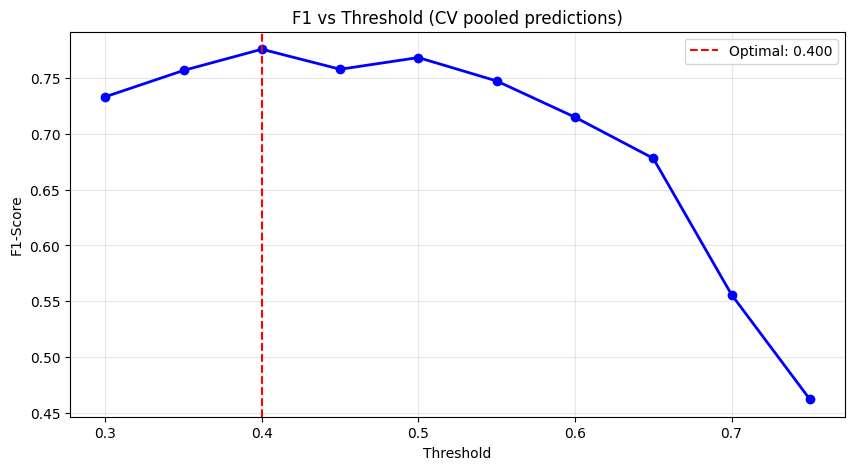


✅ Use this threshold in prediction.py: 0.400


In [30]:
# Cell 10: Find Optimal Threshold from Cross-Validation
print("\n" + "=" * 60)
print("FINDING OPTIMAL THRESHOLD FROM CROSS-VALIDATION")
print("=" * 60)

all_true = np.array(all_true)
all_probs = np.array(all_probs)

best_threshold = 0.5
best_f1 = -1

for threshold in np.arange(0.30, 0.80, 0.01):
    preds = (all_probs >= threshold).astype(int)
    f1 = f1_score(all_true, preds, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

preds_best = (all_probs >= best_threshold).astype(int)
acc_best = accuracy_score(all_true, preds_best)

print(f"\n📊 Optimal Threshold: {best_threshold:.3f}")
print(f"   Best F1 at this threshold: {best_f1:.4f}")
print(f"   Accuracy at this threshold: {acc_best:.4f}")

# Optional threshold curve
thresholds = np.arange(0.30, 0.80, 0.05)
f1_scores = [f1_score(all_true, (all_probs >= t).astype(int), zero_division=0) for t in thresholds]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, "bo-", linewidth=2)
plt.axvline(x=best_threshold, color="r", linestyle="--", label=f"Optimal: {best_threshold:.3f}")
plt.xlabel("Threshold")
plt.ylabel("F1-Score")
plt.title("F1 vs Threshold (CV pooled predictions)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n✅ Use this threshold in prediction.py: {best_threshold:.3f}")

In [31]:
# Cell 11: Save Final Model for Deployment
print("\n" + "=" * 60)
print("SAVING FINAL MODEL FOR DEPLOYMENT")
print("=" * 60)

print("Training final model on ALL samples...")

# same architecture/hparams family as before
history_final, final_model = train_model(
    audio_emb,
    text_emb,
    clinical_features,
    y,
    audio_emb,            # keep your original flow
    text_emb,
    clinical_features,
    y,
    lr=2e-5,
    epochs=30,
    dropout=0.15,
    verbose=True,
)

final_model_path = os.path.join(MODEL_SAVE_PATH, "multimodal_clinical_model.pth")
torch.save(final_model.state_dict(), final_model_path)

threshold_info = {
    "optimal_threshold": float(best_threshold),
    "cv_mean_accuracy": float(np.mean(cv_results["acc"])),
    "cv_std_accuracy": float(np.std(cv_results["acc"])),
    "cv_mean_precision": float(np.mean(cv_results["precision"])),
    "cv_mean_recall": float(np.mean(cv_results["recall"])),
    "cv_mean_f1": float(np.mean(cv_results["f1"])),
    "cv_mean_auc": float(np.mean(cv_results["auc"])),
    "training_date": str(pd.Timestamp.now()),
}

import json
threshold_path = os.path.join(MODEL_SAVE_PATH, "model_info.json")
with open(threshold_path, "w") as f:
    json.dump(threshold_info, f, indent=2)

print(f"\n✅ Model saved to: {final_model_path}")
print(f"✅ Threshold info saved to: {threshold_path}")
print(f"   Optimal threshold: {best_threshold:.3f}")


SAVING FINAL MODEL FOR DEPLOYMENT
Training final model on ALL samples...

 Epoch |   Train Loss |  Train Acc |     Val Loss |    Val Acc
-----------------------------------------------------------------
     1 |       0.7044 |     0.5125 |       0.6888 |     0.5513
     2 |       0.6877 |     0.5399 |       0.6812 |     0.5262
     3 |       0.6792 |     0.5991 |       0.6710 |     0.6150
     4 |       0.6742 |     0.6150 |       0.6613 |     0.7494
     5 |       0.6694 |     0.6515 |       0.6537 |     0.7882
     6 |       0.6621 |     0.6629 |       0.6469 |     0.7836
     7 |       0.6553 |     0.6834 |       0.6401 |     0.7995
     8 |       0.6463 |     0.7107 |       0.6335 |     0.7973
     9 |       0.6408 |     0.7062 |       0.6274 |     0.7995
    10 |       0.6376 |     0.7472 |       0.6218 |     0.7745
    11 |       0.6313 |     0.7335 |       0.6158 |     0.7768
    12 |       0.6158 |     0.7585 |       0.6096 |     0.7995
    13 |       0.6215 |     0.7472 |    

In [32]:
# Cell 12: Verify Model Saved
model_path = os.path.join(MODEL_SAVE_PATH, "multimodal_clinical_model.pth")
if os.path.exists(model_path):
    size = os.path.getsize(model_path) / (1024 * 1024)
    print(f"✅ Model found! Size: {size:.2f} MB")
    print(f"   Location: {model_path}")
else:
    print(f"❌ Model not found at {model_path}")

✅ Model found! Size: 21.74 MB
   Location: C:\alzheimers_detection\models\multimodal_clinical_model.pth



REPORT METRICS & FIGURES


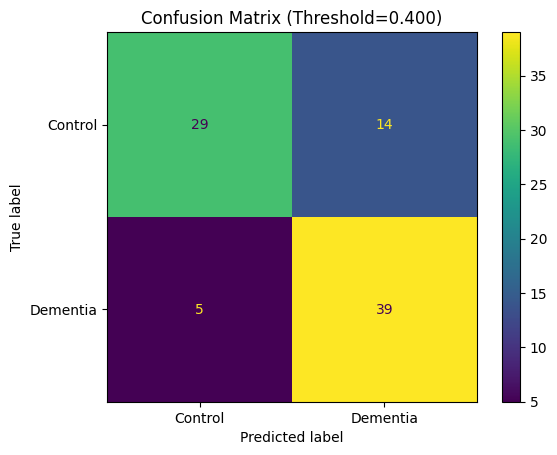

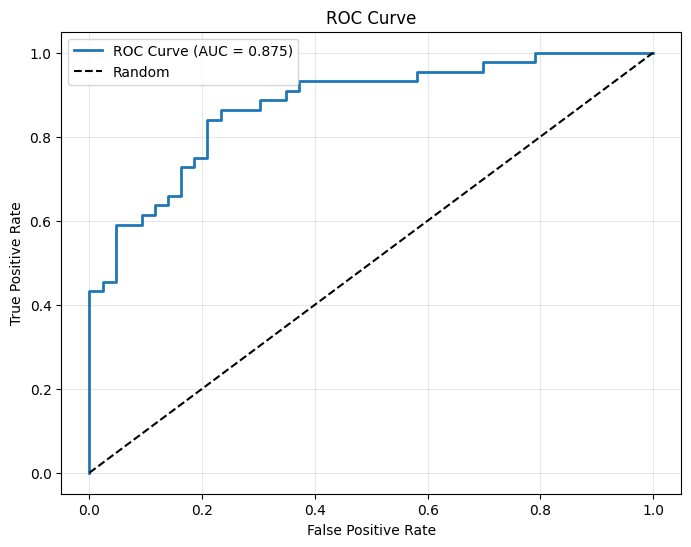


📊 Final Report Metrics:
   Validation Accuracy: 78.16%
   Precision: 0.7358
   Recall: 0.8864
   F1-Score: 0.8041
   AUC-ROC: 0.8753


In [33]:
# Cell 12: Generate Report Metrics & Figures
print("\n" + "=" * 60)
print("REPORT METRICS & FIGURES")
print("=" * 60)

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    recall_score,
    precision_score,
    f1_score,
)

# Get predictions from best model on validation set
best_model.eval()
with torch.no_grad():
    X_audio_val = torch.FloatTensor(audio_emb[val_idx]).to(device)
    X_text_val = torch.FloatTensor(text_emb[val_idx]).to(device)
    X_clinical_val = torch.FloatTensor(clinical_features[val_idx]).to(device)
    outputs = best_model(X_audio_val, X_text_val, X_clinical_val)
    probs = torch.softmax(outputs, dim=1).cpu().numpy()
    preds = (probs[:, 1] > best_threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(y[val_idx], preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Control", "Dementia"]
)
disp.plot()
plt.title(f"Confusion Matrix (Threshold={best_threshold:.3f})")
plt.savefig(os.path.join(MODEL_SAVE_PATH, "confusion_matrix.png"), dpi=150)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y[val_idx], probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(MODEL_SAVE_PATH, "roc_curve.png"), dpi=150)
plt.show()

print(f"\n📊 Final Report Metrics:")
print(f"   Validation Accuracy: {accuracy_score(y[val_idx], preds)*100:.2f}%")
print(f"   Precision: {precision_score(y[val_idx], preds):.4f}")
print(f"   Recall: {recall_score(y[val_idx], preds):.4f}")
print(f"   F1-Score: {f1_score(y[val_idx], preds):.4f}")
print(f"   AUC-ROC: {roc_auc:.4f}")


FINAL MODEL EVALUATION (Deployment Model)


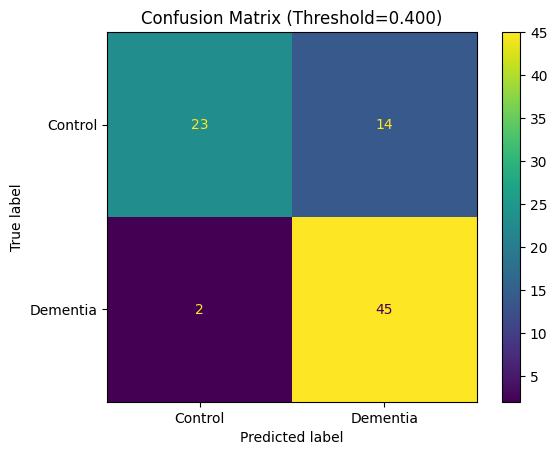

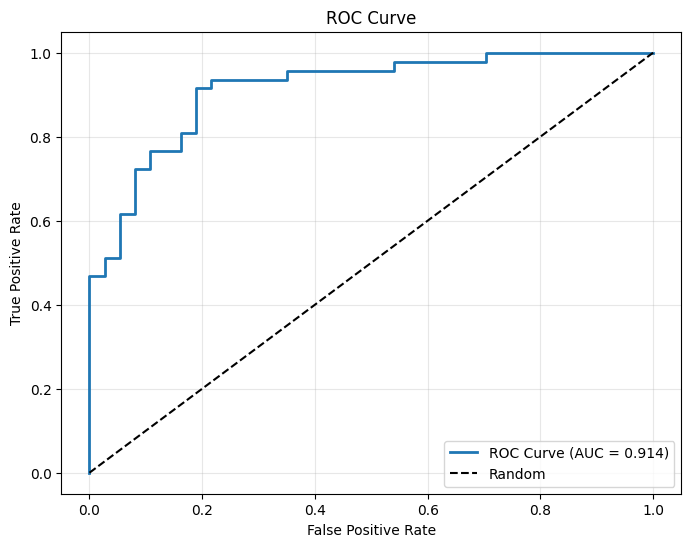


📊 Final Report Metrics (model used for prediction)
   Accuracy:    80.95%
   Precision:   0.7627
   Recall/Sens: 0.9574
   Specificity: 0.6216
   F1-Score:    0.8491
   AUC-ROC:     0.9143

Confusion Matrix: TN=23, FP=14, FN=2, TP=45
NPV: 0.9200

Classification Report:
              precision    recall  f1-score   support

     Control       0.92      0.62      0.74        37
    Dementia       0.76      0.96      0.85        47

    accuracy                           0.81        84
   macro avg       0.84      0.79      0.80        84
weighted avg       0.83      0.81      0.80        84



In [34]:
# Cell 13: Evaluation Metrics for FINAL DEPLOYMENT MODEL
print("\n" + "=" * 60)
print("FINAL MODEL EVALUATION (Deployment Model)")
print("=" * 60)

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
    recall_score, precision_score, f1_score, accuracy_score
)

# Evaluate final_model on single validation split for consistent report
final_model.eval()
with torch.no_grad():
    X_audio_eval = torch.FloatTensor(audio_emb[val_idx_single]).to(device)
    X_text_eval = torch.FloatTensor(text_emb[val_idx_single]).to(device)
    X_clinical_eval = torch.FloatTensor(clinical_features[val_idx_single]).to(device)

    outputs_eval = final_model(X_audio_eval, X_text_eval, X_clinical_eval)
    probs_eval = torch.softmax(outputs_eval, dim=1).cpu().numpy()
    y_prob = probs_eval[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)
    y_true = y[val_idx_single]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "Dementia"])
disp.plot()
plt.title(f"Confusion Matrix (Threshold={best_threshold:.3f})")
plt.savefig(os.path.join(MODEL_SAVE_PATH, "confusion_matrix.png"), dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(MODEL_SAVE_PATH, "roc_curve.png"), dpi=150)
plt.show()

# Core metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)  # sensitivity
f1 = f1_score(y_true, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0

print(f"\n📊 Final Report Metrics (model used for prediction)")
print(f"   Accuracy:    {acc*100:.2f}%")
print(f"   Precision:   {prec:.4f}")
print(f"   Recall/Sens: {rec:.4f}")
print(f"   Specificity: {specificity:.4f}")
print(f"   F1-Score:    {f1:.4f}")
print(f"   AUC-ROC:     {roc_auc:.4f}")
print(f"\nConfusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"NPV: {npv:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Control", "Dementia"], zero_division=0))